### sinusoidal源代码

In [1]:
import numpy as np
import torch

In [2]:
def create_sinusoidal_embeddings(n_pos, dim, out):
    position_enc = np.array([[pos / np.power(10000, 2 * (j // 2) / dim) for j in range(dim)] for pos in range(n_pos)])
    out.requires_grad = False
    out[:, 0::2] = torch.FloatTensor(np.sin(position_enc[:, 0::2]))
    out[:, 1::2] = torch.FloatTensor(np.cos(position_enc[:, 1::2]))
    out.detach_()


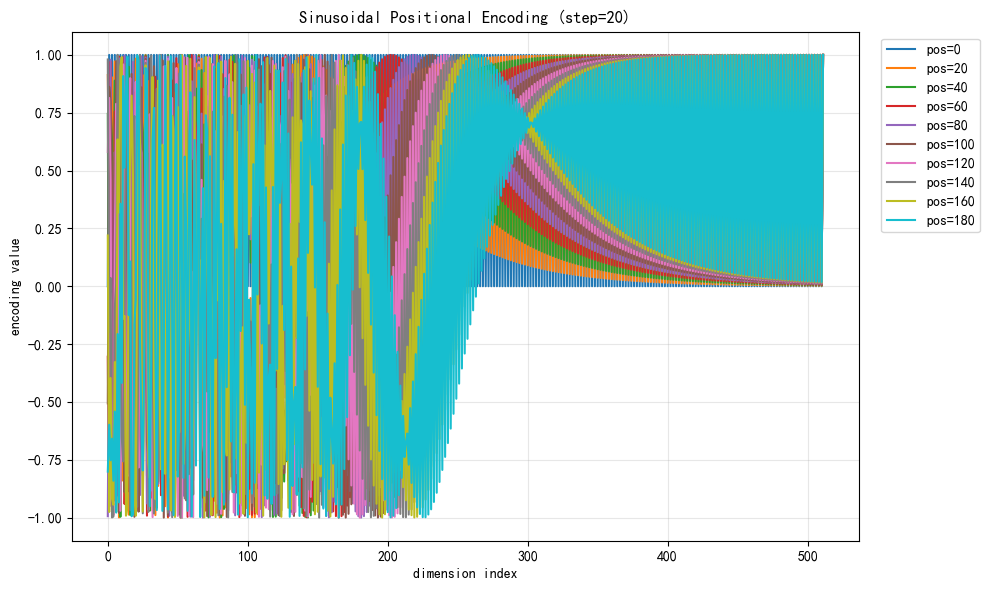

In [3]:
import matplotlib.pyplot as plt
n_pos = 200
dim=512
out=torch.zeros(n_pos, dim)
create_sinusoidal_embeddings(n_pos, dim, out)

# 准备画图
plt.figure(figsize=(10, 6))
dim_idx = np.arange(dim)          # 横坐标


for pos in range(0, n_pos, 20):    
    y = out[pos].numpy()          
    plt.plot(dim_idx, y, label=f'pos={pos}')

plt.title('Sinusoidal Positional Encoding (step=20)')
plt.xlabel('dimension index')
plt.ylabel('encoding value')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

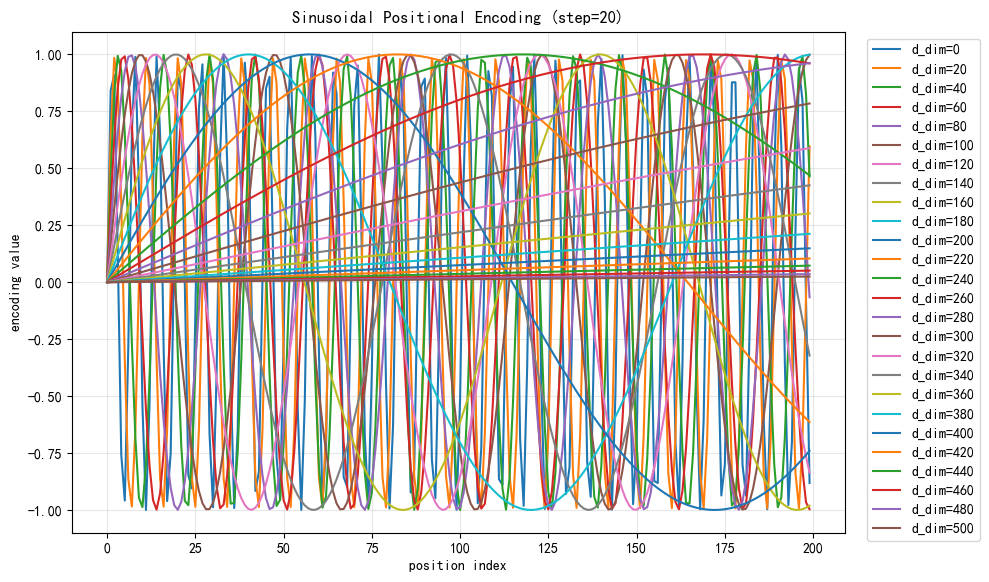

In [4]:
plt.figure(figsize=(10, 6))
dim_idx = np.arange(n_pos)          # 横坐标


for d_dim in range(0, dim, 20):     
    y = out[:,d_dim].numpy()         
    plt.plot(dim_idx, y, label=f'd_dim={d_dim}')

plt.title('Sinusoidal Positional Encoding (step=20)')
plt.xlabel('position index')
plt.ylabel('encoding value')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### rope 源代码

In [7]:

import torch.nn as nn
from typing import Callable

class Qwen3RotaryEmbedding(nn.Module):
    inv_freq: torch.Tensor  # fix linting for `register_buffer`

    def __init__(self, device=None,dim=int):
        super().__init__()

        inv_freq, self.attention_scaling = self._compute_default_rope_parameters(device, dim)
        self.register_buffer("inv_freq", inv_freq, persistent=False)

    @torch.no_grad()
   # power user: used with advanced RoPE types (e.g. dynamic rope)
    def forward(self, x, position_ids):
        inv_freq_expanded = self.inv_freq[None, :, None].float().expand(position_ids.shape[0], -1, 1).to(x.device)
        position_ids_expanded = position_ids[:, None, :].float()

        device_type = x.device.type if isinstance(x.device.type, str) and x.device.type != "mps" else "cpu"
        with torch.autocast(device_type=device_type, enabled=False):  # Force float32
            freqs = (inv_freq_expanded.float() @ position_ids_expanded.float()).transpose(1, 2)
            emb = torch.cat((freqs, freqs), dim=-1)
            cos = emb.cos() * self.attention_scaling
            sin = emb.sin() * self.attention_scaling

        return cos.to(dtype=x.dtype), sin.to(dtype=x.dtype)
    def _compute_default_rope_parameters(
            self,
            device,
            dim,
        ) -> tuple["torch.Tensor", float]:

        base = 1e4
        attention_factor = 1.0  # Unused in this type of RoPE
        # Compute the inverse frequencies
        inv_freq = 1.0 / (base ** (torch.arange(0, dim, 2, dtype=torch.int64).to(device=device, dtype=torch.float) / dim))
        return inv_freq, attention_factor

def qwen_06b_apply_rope_example():
    rote_embedding = Qwen3RotaryEmbedding(device="cpu",dim=128)
    input=torch.randn(1,27, 128, dtype=torch.float32)
    cos, sin = rote_embedding.forward(x=input, position_ids=torch.arange(input.shape[1]).unsqueeze(0))

    query_states = torch.randn(1, 27, 128, dtype=torch.float32) 
    key_states = torch.randn(1, 27, 128, dtype=torch.float32)
    query_states, key_states = apply_rotary_pos_emb(query_states, key_states, cos, sin)
    return query_states, key_states

def apply_rotary_pos_emb(q, k, cos, sin):
    q_embed = (q * cos) + (rotate_half(q) * sin)
    k_embed = (k * cos) + (rotate_half(k) * sin)
    return q_embed, k_embed
def rotate_half(x):
    """Rotates half the hidden dims of the input."""
    x1 = x[..., : x.shape[-1] // 2]
    x2 = x[..., x.shape[-1] // 2 :]
    return torch.cat((-x2, x1), dim=-1)


q_embed,k_embed=qwen_06b_apply_rope_example()
